In [1]:
# Pobieramy odpowiednie pakiety
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
import sklearn.model_selection as skm
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

In [2]:
# Wczytanie danych
X_train=pd.read_csv("X_train.csv")
y_train=pd.read_csv("y_train.csv")
X_test=pd.read_csv("X_test.csv")

## Przegląd danych

In [3]:
# Zastępujemy braki danych Nan
X_train.replace([-9,-8,-7],np.nan,inplace=True)
X_test.replace([-9,-8,-7],np.nan,inplace=True)

In [4]:
X_train

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,589,79.0,255.0,14.0,99.0,29.0,0.0,0.0,97.0,NaN,...,67.0,NaN,0.0,0.0,70.0,60.0,2.0,3.0,0.0,71.0
1,7726,77.0,61.0,2.0,33.0,14.0,0.0,0.0,100.0,NaN,...,7.0,21.0,0.0,0.0,27.0,NaN,4.0,1.0,0.0,56.0
2,48,55.0,114.0,6.0,59.0,19.0,0.0,0.0,89.0,5.0,...,53.0,0.0,1.0,1.0,97.0,90.0,8.0,2.0,6.0,100.0
3,2343,75.0,195.0,2.0,64.0,36.0,0.0,0.0,100.0,NaN,...,29.0,NaN,2.0,2.0,54.0,79.0,9.0,6.0,2.0,83.0
4,5336,77.0,147.0,3.0,65.0,15.0,0.0,0.0,93.0,30.0,...,33.0,0.0,3.0,3.0,21.0,37.0,2.0,2.0,0.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,1158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3656,1121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3657,7221,62.0,161.0,1.0,60.0,16.0,1.0,0.0,79.0,4.0,...,16.0,0.0,1.0,1.0,20.0,25.0,4.0,2.0,0.0,47.0
3658,1618,85.0,231.0,4.0,77.0,14.0,1.0,0.0,93.0,67.0,...,20.0,0.0,0.0,0.0,0.0,59.0,1.0,1.0,0.0,38.0


In [5]:
X_test

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,8119,83,272.0,2,100,27,0,0,100,NaN,...,31,3.0,1,1,8.0,NaN,8.0,1.0,1.0,75.0
1,4180,78,141.0,6,63,22,0,0,100,NaN,...,45,0.0,0,0,46.0,38.0,2.0,3.0,1.0,63.0
2,68,66,176.0,11,81,43,0,0,98,3.0,...,39,0.0,2,2,36.0,64.0,3.0,4.0,1.0,47.0
3,5934,73,131.0,4,63,19,1,0,85,20.0,...,62,NaN,1,1,25.0,17.0,1.0,4.0,NaN,100.0
4,7127,81,148.0,1,72,16,0,0,94,62.0,...,39,0.0,2,2,0.0,94.0,0.0,3.0,NaN,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,9585,84,157.0,3,74,35,0,0,100,NaN,...,11,NaN,3,3,2.0,5.0,1.0,3.0,0.0,44.0
1281,9674,87,151.0,5,82,29,0,0,100,NaN,...,73,10.0,0,0,9.0,60.0,1.0,6.0,0.0,70.0
1282,1978,73,184.0,5,69,13,0,0,85,5.0,...,23,0.0,2,2,8.0,92.0,1.0,2.0,0.0,43.0
1283,8779,58,87.0,2,42,34,0,0,100,NaN,...,34,NaN,5,4,70.0,92.0,12.0,3.0,2.0,75.0


In [6]:
y_train

,Unnamed: 0,RiskPerformance
0,589,Bad
1,7726,Bad
2,48,Bad
3,2343,Bad
4,5336,Bad
...,...,...
3655,1158,Bad
3656,1121,Good
3657,7221,Good
3658,1618,Bad


In [7]:
X_train.info()
X_test.info()
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3660 non-null   int64  
 1   X1          3453 non-null   float64
 2   X2          3386 non-null   float64
 3   X3          3457 non-null   float64
 4   X4          3457 non-null   float64
 5   X5          3457 non-null   float64
 6   X6          3457 non-null   float64
 7   X7          3457 non-null   float64
 8   X8          3457 non-null   float64
 9   X9          1709 non-null   float64
 10  X10         3457 non-null   float64
 11  X11         3457 non-null   float64
 12  X12         3457 non-null   float64
 13  X13         3457 non-null   float64
 14  X14         3457 non-null   float64
 15  X15         2653 non-null   float64
 16  X16         3457 non-null   float64
 17  X17         3457 non-null   float64
 18  X18         3392 non-null   float64
 19  X19         2212 non-null  

array([[<AxesSubplot: title={'center': 'Unnamed: 0'}>,
        <AxesSubplot: title={'center': 'X1'}>,
        <AxesSubplot: title={'center': 'X2'}>,
        <AxesSubplot: title={'center': 'X3'}>,
        <AxesSubplot: title={'center': 'X4'}>],
       [<AxesSubplot: title={'center': 'X5'}>,
        <AxesSubplot: title={'center': 'X6'}>,
        <AxesSubplot: title={'center': 'X7'}>,
        <AxesSubplot: title={'center': 'X8'}>,
        <AxesSubplot: title={'center': 'X9'}>],
       [<AxesSubplot: title={'center': 'X10'}>,
        <AxesSubplot: title={'center': 'X11'}>,
        <AxesSubplot: title={'center': 'X12'}>,
        <AxesSubplot: title={'center': 'X13'}>,
        <AxesSubplot: title={'center': 'X14'}>],
       [<AxesSubplot: title={'center': 'X15'}>,
        <AxesSubplot: title={'center': 'X16'}>,
        <AxesSubplot: title={'center': 'X17'}>,
        <AxesSubplot: title={'center': 'X18'}>,
        <AxesSubplot: title={'center': 'X19'}>],
       [<AxesSubplot: title={'center':

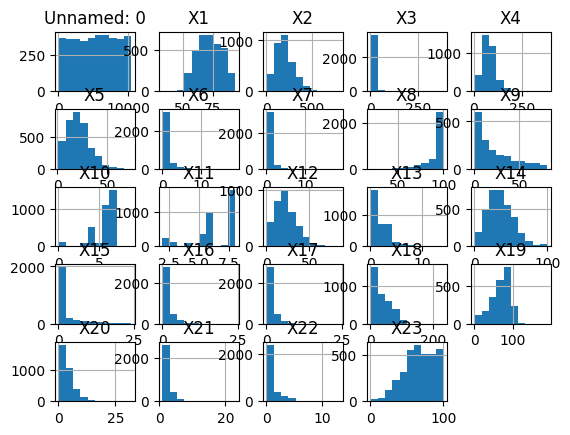

In [8]:
X_train.hist()

array([[<AxesSubplot: title={'center': 'Unnamed: 0'}>,
        <AxesSubplot: title={'center': 'X1'}>,
        <AxesSubplot: title={'center': 'X2'}>,
        <AxesSubplot: title={'center': 'X3'}>,
        <AxesSubplot: title={'center': 'X4'}>],
       [<AxesSubplot: title={'center': 'X5'}>,
        <AxesSubplot: title={'center': 'X6'}>,
        <AxesSubplot: title={'center': 'X7'}>,
        <AxesSubplot: title={'center': 'X8'}>,
        <AxesSubplot: title={'center': 'X9'}>],
       [<AxesSubplot: title={'center': 'X10'}>,
        <AxesSubplot: title={'center': 'X11'}>,
        <AxesSubplot: title={'center': 'X12'}>,
        <AxesSubplot: title={'center': 'X13'}>,
        <AxesSubplot: title={'center': 'X14'}>],
       [<AxesSubplot: title={'center': 'X15'}>,
        <AxesSubplot: title={'center': 'X16'}>,
        <AxesSubplot: title={'center': 'X17'}>,
        <AxesSubplot: title={'center': 'X18'}>,
        <AxesSubplot: title={'center': 'X19'}>],
       [<AxesSubplot: title={'center':

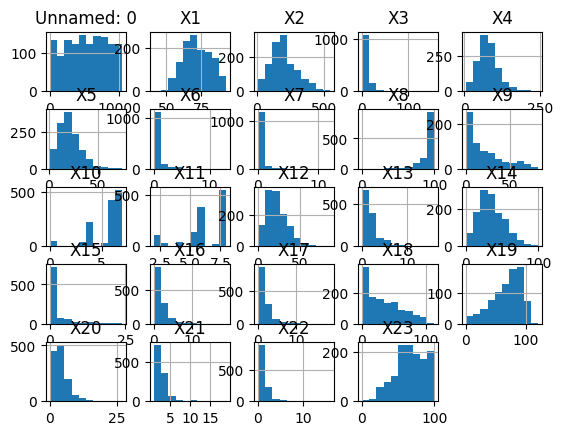

In [9]:
X_test.hist()

In [10]:
X_train.describe()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,3660.000000,3453.000000,3386.000000,3457.000000,3457.000000,3457.000000,3457.000000,3457.000000,3457.000000,1709.000000,...,3457.000000,2653.000000,3457.000000,3457.000000,3392.000000,2212.000000,3401.000000,3137.000000,3223.000000,3447.000000
mean,5268.236339,72.245584,198.727112,9.958056,78.558866,20.929997,0.577090,0.382123,92.538039,22.209479,...,34.718831,2.437618,1.485392,1.426092,34.548349,67.778029,4.038812,2.436085,1.075706,66.224543
std,3013.961271,9.962179,97.279900,14.514111,34.146718,11.246386,1.276309,1.051649,11.665392,20.641342,...,17.895455,4.740272,2.007041,1.959616,28.801173,24.280641,3.010808,1.560170,1.496896,22.036680
min,5.000000,33.000000,4.000000,0.000000,4.000000,1.000000,0.000000,0.000000,20.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2669.750000,65.000000,133.000000,3.000000,57.000000,13.000000,0.000000,0.000000,90.000000,5.000000,...,22.000000,0.000000,0.000000,0.000000,9.000000,53.000000,2.000000,1.000000,0.000000,50.000000
50%,5334.000000,72.000000,184.000000,6.000000,76.000000,20.000000,0.000000,0.000000,98.000000,15.000000,...,33.000000,0.000000,1.000000,1.000000,29.000000,73.000000,3.000000,2.000000,1.000000,67.000000
75%,7797.250000,80.000000,255.000000,12.000000,97.000000,28.000000,1.000000,0.000000,100.000000,34.000000,...,45.000000,3.000000,2.000000,2.000000,55.000000,87.000000,5.000000,3.000000,2.000000,83.000000
max,10455.000000,94.000000,789.000000,383.000000,383.000000,74.000000,19.000000,19.000000,100.000000,81.000000,...,100.000000,24.000000,24.000000,24.000000,232.000000,190.000000,32.000000,23.000000,13.000000,100.000000


In [11]:
X_test.describe()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,1285.000000,1285.00000,1257.000000,1285.000000,1285.000000,1285.000000,1285.000000,1285.000000,1285.000000,679.000000,...,1285.000000,973.000000,1285.000000,1285.000000,1263.000000,861.000000,1266.000000,1184.000000,1214.000000,1284.000000
mean,5321.432685,71.89572,201.291965,9.444358,78.519066,21.068482,0.597665,0.372763,91.827237,21.338733,...,34.673152,2.474820,1.420233,1.364981,33.924782,68.147503,4.074250,2.511824,1.057661,66.102804
std,2948.218633,9.72920,97.927699,12.061088,34.354424,11.221155,1.266939,0.953125,12.376104,20.584529,...,18.095169,4.783656,1.905287,1.855325,27.859676,24.247327,3.116832,1.790799,1.595533,21.555244
min,11.000000,41.00000,8.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2818.000000,64.00000,137.000000,3.000000,56.000000,13.000000,0.000000,0.000000,88.000000,5.000000,...,21.000000,0.000000,0.000000,0.000000,9.000000,53.000000,2.000000,1.000000,0.000000,50.000000
50%,5326.000000,72.00000,189.000000,6.000000,75.000000,20.000000,0.000000,0.000000,97.000000,14.000000,...,33.000000,0.000000,1.000000,1.000000,29.000000,73.000000,3.000000,2.000000,1.000000,67.000000
75%,7857.000000,80.00000,255.000000,12.000000,96.000000,27.000000,1.000000,0.000000,100.000000,32.000000,...,45.000000,3.000000,2.000000,2.000000,54.000000,88.000000,5.000000,3.000000,2.000000,82.000000
max,10458.000000,93.00000,546.000000,156.000000,244.000000,75.000000,13.000000,12.000000,100.000000,83.000000,...,100.000000,24.000000,19.000000,19.000000,113.000000,121.000000,27.000000,19.000000,16.000000,100.000000


In [12]:
np.mean(y_train["RiskPerformance"]=="Bad")

0.5256830601092897

Możemy zauważyć dużo braków danych, które trzeba uzupełnić. Zmienne wymagają także przeskalowania (obecność outlierów, a także duża skośność niektórych rozkładów). Mamy dość dużo zmiennych, więc być może niektóre będzie można uznać za nieistotne.

## Przygotowanie danych

In [13]:
len(X_train["Unnamed: 0"].unique()) # Unikalne wartości w nieopisanej kolumnie; najprawdopodobniej unikalny numer klienta

3660

In [14]:
# Wyrzucamy kolumnę nieopisaną w danych (nic nie wnosi ze względu na same unikalne wrtości)  
X_train=X_train.drop("Unnamed: 0",axis=1)
X_test=X_test.drop("Unnamed: 0",axis=1)
y_train=y_train.drop("Unnamed: 0",axis=1)

In [15]:
# Będziemy traktować zmienne X10 i X11 jak kategoryczne
X_train["X10"]=X_train["X10"].astype("object")
X_train["X11"]=X_train["X11"].astype("object")
X_test["X10"]=X_test["X10"].astype("object")
X_test["X11"]=X_test["X11"].astype("object")

In [16]:
# Podzielenie za numeryczne i kategoryczne
numerical_features = list(X_train.dtypes[(X_train.dtypes != 'object') & (X_train.dtypes != 'category')].index)
categorical_features = list(X_train.dtypes[(X_train.dtypes == 'object') | (X_train.dtypes == 'category')].index)

In [17]:
columns_to_log=["X3","X4","X5","X6","X7","X9","X13","X15","X16","X17","X18","X20","X21","X22"]
columns_to_inverse=["X8","X19"]
X_train[columns_to_log] = X_train[columns_to_log].apply(np.log1p)
X_test[columns_to_log] = X_test[columns_to_log].apply(np.log1p)
X_train[columns_to_inverse] = (1/(X_train[columns_to_inverse]+1)).apply(np.log1p)
X_test[columns_to_inverse] = (1/(X_test[columns_to_inverse]+1)).apply(np.log1p)

In [18]:
# Uzupełnianie braków
preprocessor = ColumnTransformer([
    ('cat', SimpleImputer(strategy="most_frequent"), categorical_features),
    ("num", IterativeImputer(max_iter=100,random_state=327177), numerical_features)
       
])

In [19]:
# Wybór istotnych zmiennych
selector= SelectFromModel(LogisticRegression(penalty="l2",random_state=327177), max_features = 20)
pipeline = Pipeline([
    ('pre', preprocessor),
    ("scaler", StandardScaler()),
    ('selector', selector),
    ('to_dataframe', FunctionTransformer(lambda X: pd.DataFrame(X,columns=X_train2.columns[X_train2.columns.isin(X_train2.columns[selector.get_support()])])))
])

In [20]:
# Podział zbioru
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train, y_train, test_size = 0.15,random_state=327177)
y_train2 = y_train2["RiskPerformance"]
y_test2 = y_test2["RiskPerformance"]

In [21]:
X_train_transformed = pipeline.fit_transform(X_train2,y_train2)

In [22]:
X_test1_transformed = pipeline.transform(X_test)

In [23]:
X_test2_transformed = pipeline.transform(X_test2)

array([[<AxesSubplot: title={'center': 'X3'}>,
        <AxesSubplot: title={'center': 'X6'}>,
        <AxesSubplot: title={'center': 'X7'}>],
       [<AxesSubplot: title={'center': 'X11'}>,
        <AxesSubplot: title={'center': 'X15'}>,
        <AxesSubplot: title={'center': 'X16'}>],
       [<AxesSubplot: title={'center': 'X17'}>,
        <AxesSubplot: title={'center': 'X22'}>, <AxesSubplot: >]],
      dtype=object)

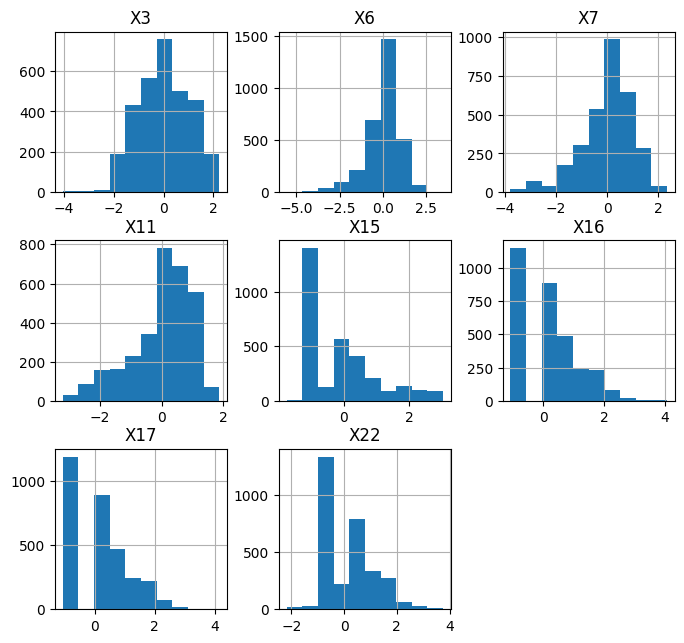

In [93]:
# Dane po transformacji 
X_train_transformed.hist(figsize=(8, 7.5))

In [25]:
# Dane po transformacji 
X_train_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3111 entries, 0 to 3110
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X3      3111 non-null   float64
 1   X6      3111 non-null   float64
 2   X7      3111 non-null   float64
 3   X11     3111 non-null   float64
 4   X15     3111 non-null   float64
 5   X16     3111 non-null   float64
 6   X17     3111 non-null   float64
 7   X22     3111 non-null   float64
dtypes: float64(8)
memory usage: 194.6 KB


## Poszukiwanie optymalnego modelu

Sprawdzimy jak zachowują się podstawowe modele na naszych danych.

In [26]:
model=[]
balanced_accuracy_train=[]
balanced_accuracy_test=[]

In [27]:
# Pierwszy model - drzewko decyzyjne
pipeline = Pipeline([
    ('tree', DecisionTreeClassifier(random_state=327177))
])

params = {
    'tree__criterion': ["gini","entropy"],
    'tree__max_depth': list(range(3,10)),
    'tree__min_samples_leaf': list(range(5,100,5)),
    'tree__min_samples_split':list(range(5,250,5))
}

grid_pipeline_tree = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [28]:
grid_pipeline_tree.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tree',
                                        DecisionTreeClassifier(random_state=327177))]),
             param_grid={'tree__criterion': ['gini', 'entropy'],
                         'tree__max_depth': [3, 4, 5, 6, 7, 8, 9],
                         'tree__min_samples_leaf': [5, 10, 15, 20, 25, 30, 35,
                                                    40, 45, 50, 55, 60, 65, 70,
                                                    75, 80, 85, 90, 95],
                         'tree__min_samples_split': [5, 10, 15, 20, 25, 30, 35,
                                                     40, 45, 50, 55, 60, 65, 70,
                                                     75, 80, 85, 90, 95, 100,
                                                     105, 110, 115, 120, 125,
                                                     130, 135, 140, 145, 150, ...]},
             scoring='balanced_accuracy')

In [29]:
(grid_pipeline_tree.score(X_train_transformed, y_train2),
grid_pipeline_tree.score(X_test2_transformed,y_test2))

(0.7200977101514134, 0.6967593824860261)

In [30]:
model.append("Drzewo decyzyjne")
balanced_accuracy_train.append(round(grid_pipeline_tree.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_tree.score(X_test2_transformed,y_test2),4))

In [31]:
# Drugi model - las losowy
pipeline = Pipeline([
    ('rf', RandomForestClassifier(max_depth=4, min_samples_leaf=40, min_samples_split=195,random_state=327177))
])

params = {
    'rf__n_estimators':list(range(50,600,50))
}

grid_pipeline_rf = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                               scoring = "balanced_accuracy")

In [32]:
grid_pipeline_rf.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('rf',
                                        RandomForestClassifier(max_depth=4,
                                                               min_samples_leaf=40,
                                                               min_samples_split=195,
                                                               random_state=327177))]),
             param_grid={'rf__n_estimators': [50, 100, 150, 200, 250, 300, 350,
                                              400, 450, 500, 550]},
             scoring='balanced_accuracy')

In [33]:
(grid_pipeline_rf.score(X_train_transformed, y_train2),
grid_pipeline_rf.score(X_test2_transformed,y_test2))

(0.7336298202431566, 0.7048442906574395)

In [34]:
model.append("Las losowy")
balanced_accuracy_train.append(round(grid_pipeline_rf.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_rf.score(X_test2_transformed,y_test2),4))

In [35]:
# Trzeci model - ExtraTrees
pipeline = Pipeline([
    ('tc', ExtraTreesClassifier(max_depth=4, min_samples_leaf=40, min_samples_split=195,random_state=327177))
])

params = {
    'tc__n_estimators':list(range(50,600,50))
}

grid_pipeline_tc = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                               scoring = "balanced_accuracy")

In [36]:
grid_pipeline_tc.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tc',
                                        ExtraTreesClassifier(max_depth=4,
                                                             min_samples_leaf=40,
                                                             min_samples_split=195,
                                                             random_state=327177))]),
             param_grid={'tc__n_estimators': [50, 100, 150, 200, 250, 300, 350,
                                              400, 450, 500, 550]},
             scoring='balanced_accuracy')

In [37]:
(grid_pipeline_tc.score(X_train_transformed, y_train2),
grid_pipeline_tc.score(X_test2_transformed,y_test2))

(0.7186724596603764, 0.6994543518764972)

In [38]:
model.append("ExtraTrees")
balanced_accuracy_train.append(round(grid_pipeline_tc.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_tc.score(X_test2_transformed,y_test2),4))

In [39]:
# Czwarty model - regresja logistyczna z karą l1
pipeline = Pipeline([
    ('lr',LogisticRegression(penalty="l1",random_state=327177))
])

params = {
    'lr__solver': ["liblinear","saga"],
    'lr__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10, 100],
    'lr__class_weight':["balanced",None]
}

grid_pipeline_lr = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring = "balanced_accuracy")

In [40]:
grid_pipeline_lr.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('lr',
                                        LogisticRegression(penalty='l1',
                                                           random_state=327177))]),
             param_grid={'lr__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10,
                                   100],
                         'lr__class_weight': ['balanced', None],
                         'lr__solver': ['liblinear', 'saga']},
             scoring='balanced_accuracy')

In [41]:
(grid_pipeline_lr.score(X_train_transformed, y_train2),
grid_pipeline_lr.score(X_test2_transformed,y_test2))

(0.7272407448845131, 0.716768698429598)

In [42]:
model.append("Regresja logistyczna (regularyzacja l1)")
balanced_accuracy_train.append(round(grid_pipeline_lr.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_lr.score(X_test2_transformed,y_test2),4))

In [43]:
# Piąty model - regresja logistyczna z karą l2
pipeline = Pipeline([
    ('lr2',LogisticRegression(penalty="l2",max_iter=1000,random_state=327177))
])

params = {
    'lr2__solver': ["liblinear","saga","lbfgs","newton-cg","newton-cholesky","sag"],
    'lr2__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10, 100],
    'lr2__class_weight':["balanced", None]
}

grid_pipeline_lr2 = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring = "balanced_accuracy")

In [44]:
grid_pipeline_lr2.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('lr2',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=327177))]),
             param_grid={'lr2__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10,
                                    100],
                         'lr2__class_weight': ['balanced', None],
                         'lr2__solver': ['liblinear', 'saga', 'lbfgs',
                                         'newton-cg', 'newton-cholesky',
                                         'sag']},
             scoring='balanced_accuracy')

In [45]:
(grid_pipeline_lr2.score(X_train_transformed, y_train2),
grid_pipeline_lr2.score(X_test2_transformed,y_test2))

(0.7272407448845131, 0.716768698429598)

In [46]:
model.append("Regresja logistyczna (regularyzacja l2)")
balanced_accuracy_train.append(round(grid_pipeline_lr2.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_lr2.score(X_test2_transformed,y_test2),4))

Text(0.5, 1.0, 'Krzywa ROC dla zbioru testowego dla drzew i regresji')

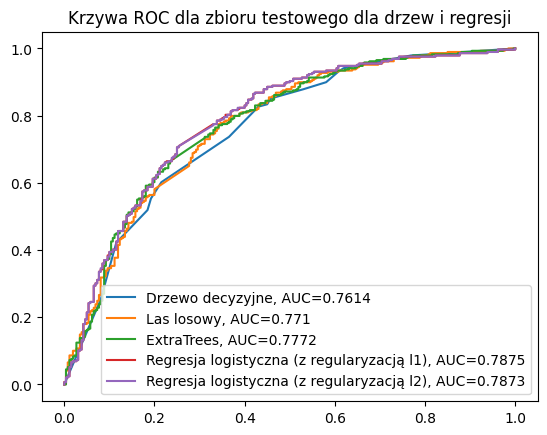

In [47]:
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_tree.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="Drzewo decyzyjne, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_tree.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_rf.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="Las losowy, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_rf.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_tc.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="ExtraTrees, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_tc.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_lr.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="Regresja logistyczna (z regularyzacją l1), AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_lr.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_lr2.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="Regresja logistyczna (z regularyzacją l2), AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_lr2.predict_proba(X_test2_transformed)[:,1]), 4)))
plt.legend()
plt.title("Krzywa ROC dla zbioru testowego dla drzew i regresji")

In [48]:
# Szósty model - wektory podpierające
pipeline = Pipeline([
    ('svc',SVC(random_state=327177))
])

params = {
    'svc__kernel': ["linear","poly","rbf","sigmoid"],
    'svc__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10, 100]
}

grid_pipeline_svc = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [49]:
grid_pipeline_svc.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('svc', SVC(random_state=327177))]),
             param_grid={'svc__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10,
                                    100],
                         'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='balanced_accuracy')

In [50]:
(grid_pipeline_svc.score(X_train_transformed, y_train2),
grid_pipeline_svc.score(X_test2_transformed,y_test2))

(0.7385414335794733, 0.7196499866915091)

In [51]:
model.append("Wektory podpierające")
balanced_accuracy_train.append(round(grid_pipeline_svc.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_svc.score(X_test2_transformed,y_test2),4))

In [52]:
svc=SVC(C=0.5, kernel='linear',probability=True)
svc.fit(X_train_transformed, y_train2)
y_pred_proba_test_svc = svc.predict_proba(X_test2_transformed)

In [53]:
# Siódmy model - LDA
pipeline = Pipeline([
    ('lda',LinearDiscriminantAnalysis())
])

params = {
    'lda__solver': ["svd", "lsqr", "eigen"]
}

grid_pipeline_lda = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [54]:
grid_pipeline_lda.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('lda', LinearDiscriminantAnalysis())]),
             param_grid={'lda__solver': ['svd', 'lsqr', 'eigen']},
             scoring='balanced_accuracy')

In [55]:
(grid_pipeline_lda.score(X_train_transformed, y_train2),
grid_pipeline_lda.score(X_test2_transformed,y_test2))

(0.7255799209368241, 0.7202289060420548)

In [56]:
model.append("LDA")
balanced_accuracy_train.append(round(grid_pipeline_lda.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_lda.score(X_test2_transformed,y_test2),4))

In [57]:
# Ósmy model - QDA
pipeline = Pipeline([
    ('qda',QuadraticDiscriminantAnalysis())
])

params = {
    'qda__reg_param': [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
}

grid_pipeline_qda = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [58]:
grid_pipeline_qda.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('qda',
                                        QuadraticDiscriminantAnalysis())]),
             param_grid={'qda__reg_param': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6,
                                            0.7, 0.8, 0.9, 1]},
             scoring='balanced_accuracy')

In [59]:
(grid_pipeline_qda.score(X_train_transformed, y_train2),
grid_pipeline_qda.score(X_test2_transformed,y_test2))

(0.7192237885681609, 0.6961937716262976)

In [60]:
model.append("QDA")
balanced_accuracy_train.append(round(grid_pipeline_qda.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_qda.score(X_test2_transformed,y_test2),4))

In [61]:
# Dziewiąty model - k-najbliższych sąsiadów
pipeline = Pipeline([
    ('knn',KNeighborsClassifier())
])

params = {
    'knn__n_neighbors': list(range(5,200,5)),
    'knn__weights': ["uniform","distance"],
    'knn__p': [1,2,3]
    
}

grid_pipeline_knn = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [62]:
grid_pipeline_knn.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3, estimator=Pipeline(steps=[('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [5, 10, 15, 20, 25, 30, 35, 40, 45,
                                              50, 55, 60, 65, 70, 75, 80, 85,
                                              90, 95, 100, 105, 110, 115, 120,
                                              125, 130, 135, 140, 145, 150, ...],
                         'knn__p': [1, 2, 3],
                         'knn__weights': ['uniform', 'distance']},
             scoring='balanced_accuracy')

In [63]:
(grid_pipeline_knn.score(X_train_transformed, y_train2),
grid_pipeline_knn.score(X_test2_transformed,y_test2))

(0.9793360433604337, 0.716196433324461)

In [64]:
model.append("k-najbliższych sąsiadów")
balanced_accuracy_train.append(round(grid_pipeline_knn.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_knn.score(X_test2_transformed,y_test2),4))

In [65]:
# Dziesiąty model - GradientBoosting
pipeline = Pipeline([
    ('gb',GradientBoostingClassifier(random_state=327177))
])

params = {
    'gb__loss': ["log_loss","exponential"],
    'gb__learning_rate': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1, 5, 10, 100, 1000],
    'gb__n_estimators': [1, 25, 50, 75, 100, 150, 200, 500, 1000]
}

grid_pipeline_gb = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [66]:
grid_pipeline_gb.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('gb',
                                        GradientBoostingClassifier(random_state=327177))]),
             param_grid={'gb__learning_rate': [0.001, 0.01, 0.1, 0.25, 0.5,
                                               0.75, 1, 5, 10, 100, 1000],
                         'gb__loss': ['log_loss', 'exponential'],
                         'gb__n_estimators': [1, 25, 50, 75, 100, 150, 200, 500,
                                              1000]},
             scoring='balanced_accuracy')

In [67]:
(grid_pipeline_gb.score(X_train_transformed, y_train2),
grid_pipeline_gb.score(X_test2_transformed,y_test2))

(0.7529810298102981, 0.7123436252328986)

In [68]:
model.append("GradientBoosting")
balanced_accuracy_train.append(round(grid_pipeline_gb.score(X_train_transformed, y_train2),4))
balanced_accuracy_test.append(round(grid_pipeline_gb.score(X_test2_transformed,y_test2),4))

Text(0.5, 1.0, 'Krzywa ROC dla zbioru testowego (pozostałe modele)')

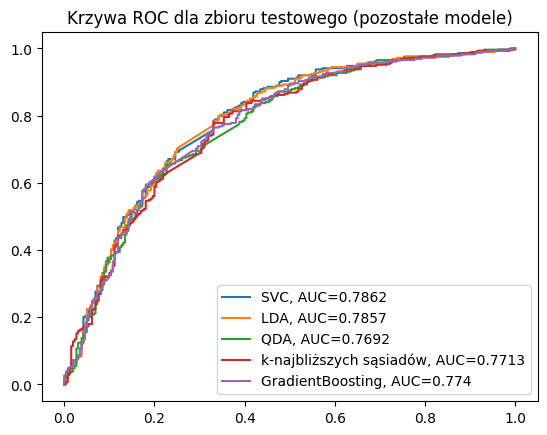

In [69]:
fpr, tpr, thresholds = roc_curve(y_test2, y_pred_proba_test_svc[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="SVC, AUC="+str(round(roc_auc_score(y_test2,  y_pred_proba_test_svc[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_lda.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="LDA, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_lda.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_qda.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="QDA, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_qda.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_knn.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="k-najbliższych sąsiadów, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_knn.predict_proba(X_test2_transformed)[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_test2, grid_pipeline_gb.predict_proba(X_test2_transformed)[:,0],pos_label="Bad")
plt.plot(fpr,tpr,label="GradientBoosting, AUC="+str(round(roc_auc_score(y_test2,  grid_pipeline_gb.predict_proba(X_test2_transformed)[:,1]), 4)))
plt.legend()
plt.title("Krzywa ROC dla zbioru testowego (pozostałe modele)")

In [70]:
# Wyniki dla wszystkich modeli
results = pd.DataFrame({'model' : model,
                        'balanced_accuracy_train' : balanced_accuracy_train,
                        'balanced_accuracy_test': balanced_accuracy_test})

In [71]:
results

,model,balanced_accuracy_train,balanced_accuracy_test
0,Drzewo decyzyjne,0.7201,0.6968
1,Las losowy,0.7336,0.7048
2,ExtraTrees,0.7187,0.6995
3,Regresja logistyczna (regularyzacja l1),0.7272,0.7168
4,Regresja logistyczna (regularyzacja l2),0.7272,0.7168
5,Wektory podpierające,0.7385,0.7196
6,LDA,0.7256,0.7202
7,QDA,0.7192,0.6962
8,k-najbliższych sąsiadów,0.9793,0.7162
9,GradientBoosting,0.7530,0.7123


Spróbujemy wykorzystacie powyższe modele do stworzenia modelu z komitetami klasyfikatorów. Wykorzystamy modele, które wykazały się największą jakością predykcji.

Najpierw stworzymy model oparty na baggingu, w którym użyjemy najbardziej jakościowego modelu.

In [72]:
# Bagging
pipeline= Pipeline([
    ('bagging', BaggingClassifier(estimator = SVC(C=0.5, kernel='linear',probability=True ,random_state=327177), random_state=327177))
                           
])
params = {
    'bagging__n_estimators': [25,50,100,150,200,250,300]
}

grid_pipeline_bag= GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                             scoring = "balanced_accuracy")

In [73]:
grid_pipeline_bag.fit(X_train_transformed, y_train2)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('bagging',
                                        BaggingClassifier(estimator=SVC(C=0.5,
                                                                        kernel='linear',
                                                                        probability=True,
                                                                        random_state=327177),
                                                          random_state=327177))]),
             param_grid={'bagging__n_estimators': [25, 50, 100, 150, 200, 250,
                                                   300]},
             scoring='balanced_accuracy')

In [74]:
(grid_pipeline_bag.score(X_train_transformed, y_train2),
grid_pipeline_bag.score(X_test2_transformed,y_test2))

(0.724530717784242, 0.7217660367314347)

Bagging nie poprawił istotnie naszego modelu.

Do votingu wykorzystamy najlepsze modele, a ich liczbę ustalimy w drodze eksperymentu.

In [75]:
m1 = SVC(C=0.5, kernel='linear',probability=True ,random_state=327177) 
m2 = LinearDiscriminantAnalysis()
m3 = LogisticRegression(C=0.25, penalty='l1', random_state=327177, solver='saga')
m4 = LogisticRegression(C=0.1, max_iter=1000, random_state=327177, solver='saga')
m5 = RandomForestClassifier(n_estimators=200, random_state=327177)
m6 = GradientBoostingClassifier(learning_rate=0.01, loss='exponential', n_estimators=500, random_state=327177)
m7 = KNeighborsClassifier(n_neighbors=40, weights='distance')
m8 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=40, min_samples_split=195, random_state=327177)
m9 = QuadraticDiscriminantAnalysis(reg_param=0.3)
m10 = ExtraTreesClassifier(n_estimators=250, random_state=327177)

In [76]:
estimators=[('svc', m1), ('lda', m2), ('lr', m3), ('lr2', m4),('rf', m5), ('gb', m6), ('knn', m7), ('t', m8),('qda',m9),('et',m10)]

In [77]:
b_a_train_v=[]
b_a_test_v=[]

In [78]:
# Voting
for i in range(2,11):
    
    voting_pipeline = Pipeline([
        ('vote', VotingClassifier(estimators=estimators[0:i],voting='soft'))
    ])
    voting_pipeline.fit(X_train_transformed, y_train2)
    y_pred_train = voting_pipeline.predict(X_train_transformed)
    y_pred_test = voting_pipeline.predict(X_test2_transformed)
    b_a_train_v.append(balanced_accuracy_score(y_train2,y_pred_train))
    b_a_test_v.append(balanced_accuracy_score(y_test2, y_pred_test))

In [79]:
b_a_test_v

[0.7200359329252063,
 0.7183058291189779,
 0.7200359329252063,
 0.7148456215065211,
 0.7184988022358265,
 0.7219590098482832,
 0.7238820867713601,
 0.7148456215065211,
 0.7200359329252063]

Text(0.5, 1.0, 'Miara balanced accuracy w zależności od liczby modeli użytych do tworzenia modelu metodą voting')

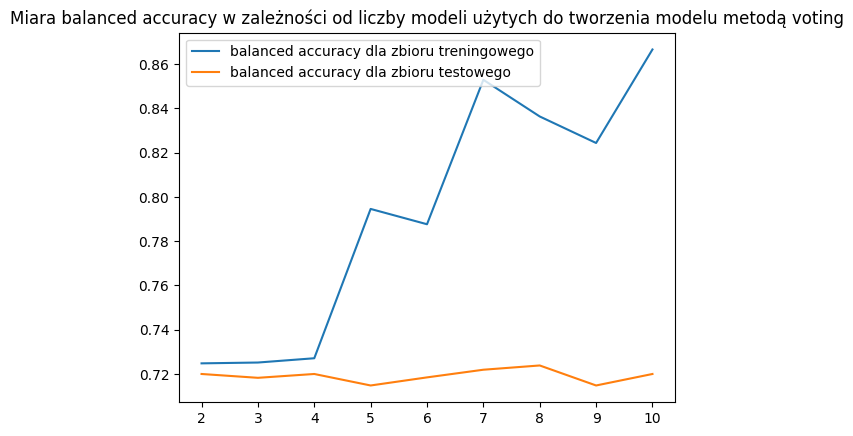

In [80]:
plt.plot([2,3,4,5,6,7,8,9,10], b_a_train_v, label="balanced accuracy dla zbioru treningowego")
plt.plot([2,3,4,5,6,7,8,9,10], b_a_test_v, label="balanced accuracy dla zbioru testowego")
plt.legend()
plt.title("Miara balanced accuracy w zależności od liczby modeli użytych do tworzenia modelu metodą voting")

Widzimy, że najoptymalnie będzie wybrać voting złożony z dziesięciu modeli.

Analogicznie jak w votingu przeprowadzimy eksperyment, który pokaże nam ile modeli powinniśmy wybrać do stackingu.

In [81]:
b_a_train_s=[]
b_a_test_s=[]

In [82]:
# Sampling
for i in range(2,11):
    stacking_pipeline = Pipeline([
                           ('stack', StackingClassifier(estimators=estimators[0:i], 
                             final_estimator=LogisticRegression(random_state=327177)))
                           ])
    stacking_pipeline.fit(X_train_transformed, y_train2)
    y_pred_train = stacking_pipeline.predict(X_train_transformed)
    y_pred_test = stacking_pipeline.predict(X_test2_transformed)
    b_a_train_s.append(balanced_accuracy_score(y_train2,y_pred_train))
    b_a_test_s.append(balanced_accuracy_score(y_test2, y_pred_test))

Text(0.5, 1.0, 'Miara balanced accuracy w zależności od liczby modeli użytych do tworzenia modelu metodą stacking')

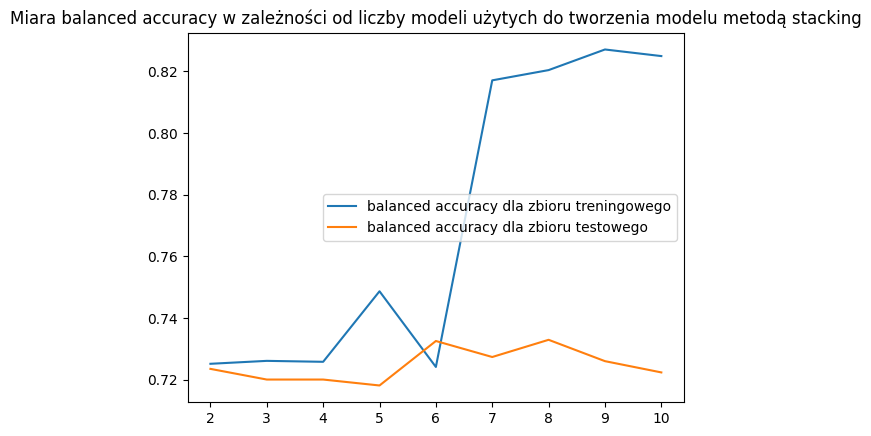

In [83]:
plt.plot([2,3,4,5,6,7,8,9,10], b_a_train_s, label="balanced accuracy dla zbioru treningowego")
plt.plot([2,3,4,5,6,7,8,9,10], b_a_test_s, label="balanced accuracy dla zbioru testowego")
plt.legend()
plt.title("Miara balanced accuracy w zależności od liczby modeli użytych do tworzenia modelu metodą stacking")

In [84]:
b_a_test_s

[0.723496140537663,
 0.7200359329252063,
 0.7200359329252063,
 0.7181128560021294,
 0.7325326058025019,
 0.7273422943838168,
 0.7329185520361992,
 0.7259981368112856,
 0.7223449560819803]

W przypadku samplingu najlepiej byłoby użyć 6 modeli. Widzimy, że użycie metod związanch z komitetami klasyfikatorów podniosło jakość predykcji. Najlepszy okazał się model wykorzystujący metodę votingu z dziesięcioma modelami. 

In [85]:
# Tworzenie ostatecznego modelu
final_model= VotingClassifier(estimators=estimators[0:10],voting='soft')

In [86]:
final_model.fit(X_train_transformed, y_train2)

VotingClassifier(estimators=[('svc',
                              SVC(C=0.5, kernel='linear', probability=True,
                                  random_state=327177)),
                             ('lda', LinearDiscriminantAnalysis()),
                             ('lr',
                              LogisticRegression(C=0.25, penalty='l1',
                                                 random_state=327177,
                                                 solver='saga')),
                             ('lr2',
                              LogisticRegression(C=0.1, max_iter=1000,
                                                 random_state=327177,
                                                 solver='saga')),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     ran...
                                                         loss='exponential',
                                                         n_estimators=500,
                                                         random_state=327177)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=40,
                                                   weights='distance')),
                             ('t',
                              DecisionTreeClassifier(max_depth=4,
                                                     min_samples_leaf=40,
                                                     min_samples_split=195,
                                                     random_state=327177)),
                             ('qda',
                              QuadraticDiscriminantAnalysis(reg_param=0.3)),
                             ('et',
                              ExtraTreesClassifier(n_estimators=250,
                                                   random_state=327177))],
                 voting='soft')

In [87]:
# Zapisywanie prawdopodobieństw przynależności do klasy 'Bad'
wyniki=final_model.predict_proba(X_test1_transformed)[:,0]